### DORAnet Pathway Visualization Tool

,Rank,FinalScore,AtomicEconomy,Steps,Byproducts,Rules
0,1,7.0,91.2%,2,0,"rule0004_13, rule0043_12"
1,2,7.0,91.2%,2,0,"rule0043_12, rule0004_13"
2,3,6.0,53.8%,2,0,"rule0126_2, rule0004_13"


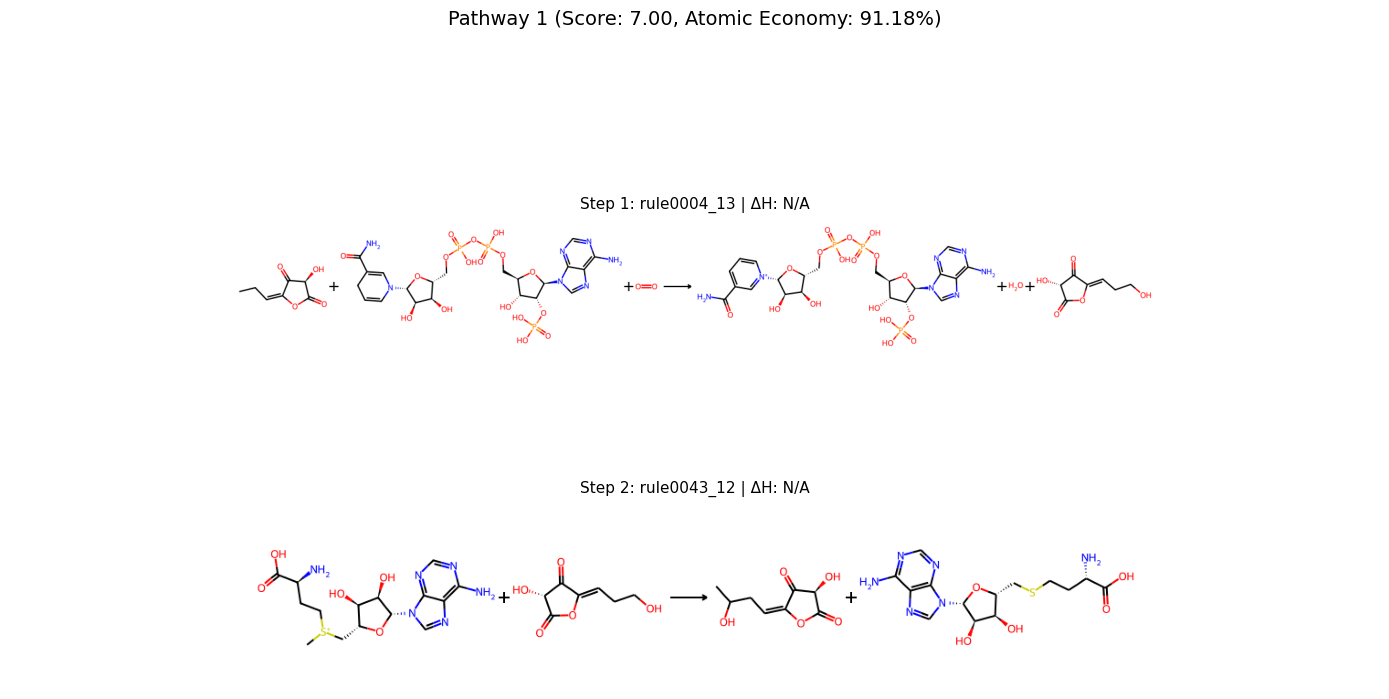

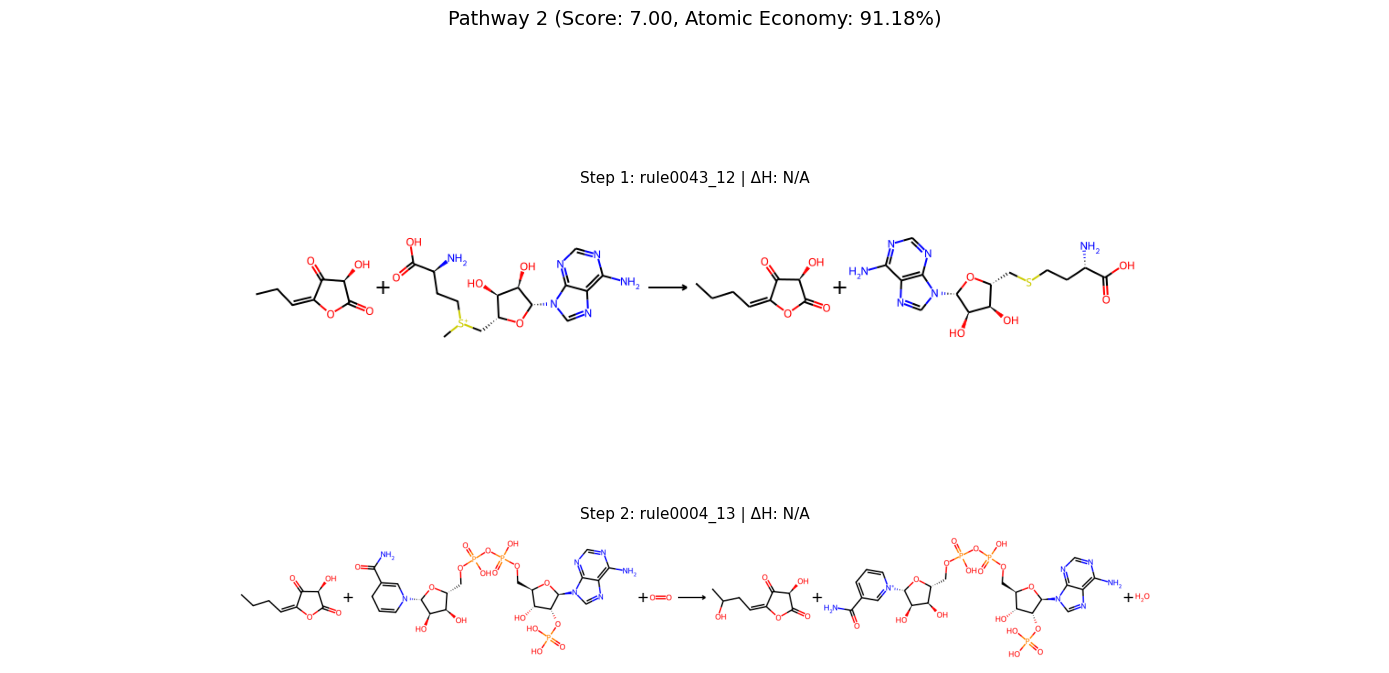

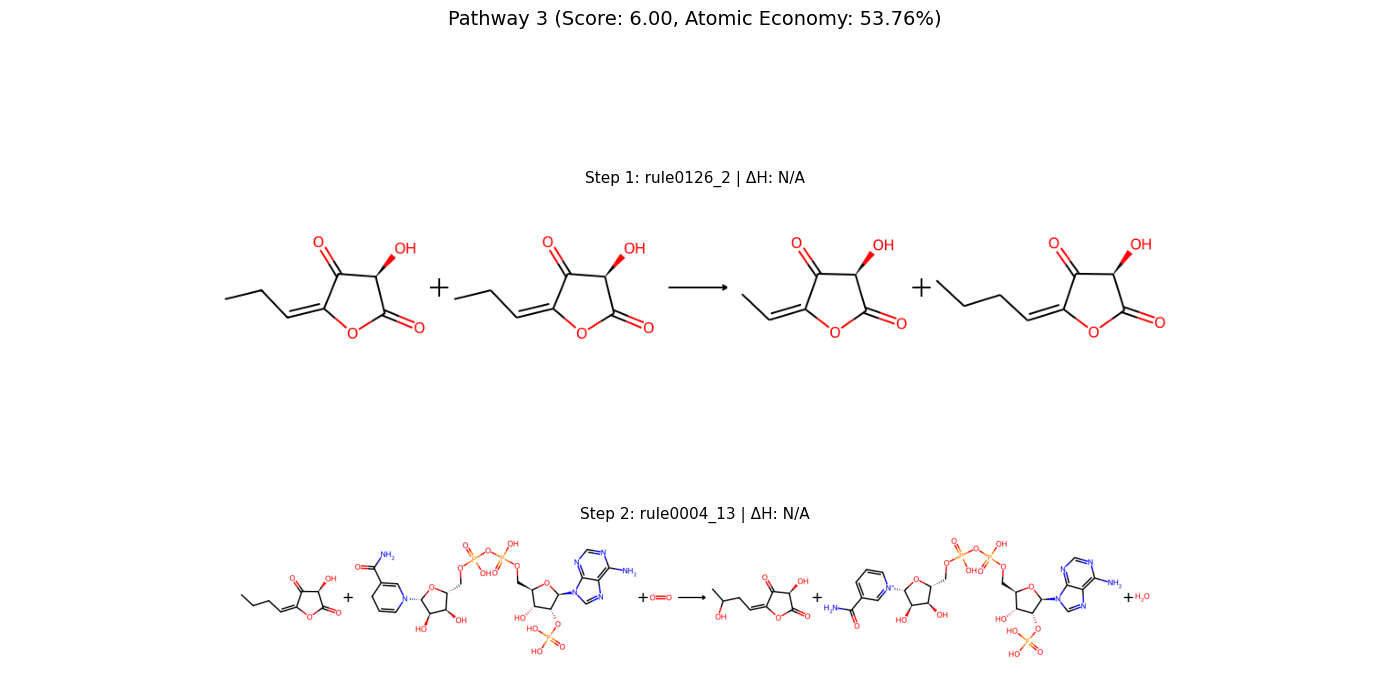

In [20]:
import re
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Tuple
import pandas as pd
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

try:
    from rdkit import Chem
    from rdkit.Chem import Draw, AllChem, rdMolDescriptors
    RDKIT_AVAILABLE = True
except ImportError:
    RDKIT_AVAILABLE = False

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150

@dataclass
class Reaction:
    smiles: str
    ruleName: str
    enthalpy: Optional[float]
    reactants: List[str] = field(default_factory=list)
    products: List[str] = field(default_factory=list)
    
    def __post_init__(self):
        if self.smiles and '>>' in self.smiles:
            reactantsStr, productsStr = self.smiles.split('>>')
            self.reactants = reactantsStr.split('.')
            self.products = productsStr.split('.')


@dataclass
class Pathway:
    ranking: int
    finalScore: float
    atomicEconomy: float
    pathwayByproduct: int
    intermediateByproduct: Dict
    reactions: List[Reaction] = field(default_factory=list)


def isNumeric(s: str) -> bool:
    try:
        float(s)
        return True
    except ValueError:
        return False


def parseSinglePathway(block: str) -> Optional[Pathway]:
    lines = block.strip().split('\n')
    ranking, finalScore, atomicEconomy = None, None, None
    pathwayByproduct, intermediateByproduct, reactions = 0, {}, []
    
    i = 0
    while i < len(lines):
        line = lines[i].strip()
        
        if line.startswith('ranking '):
            ranking = int(line.split()[1])
        elif line.startswith('final score '):
            finalScore = float(line.split()[-1])
        elif line.startswith('atomic economy '):
            atomicEconomy = float(line.split()[-1])
        elif line.startswith('pathway by-product '):
            pathwayByproduct = int(line.split()[-1])
        elif line.startswith('intermediate by-product '):
            dictStr = line.replace('intermediate by-product ', '')
            try:
                intermediateByproduct = eval(dictStr)
            except:
                intermediateByproduct = {}
        elif line.startswith('reaction SMILES'):
            i += 1
            reactionSmiles, ruleNames, enthalpies = [], [], []
            
            while i < len(lines) and '>>' in lines[i]:
                reactionSmiles.append(lines[i].strip())
                i += 1
            while i < len(lines) and lines[i].strip().startswith('rule'):
                ruleNames.append(lines[i].strip())
                i += 1
            while i < len(lines) and (lines[i].strip() == 'No_Thermo' or isNumeric(lines[i].strip())):
                enth = lines[i].strip()
                enthalpies.append(None if enth == 'No_Thermo' else float(enth))
                i += 1
            
            for j, smi in enumerate(reactionSmiles):
                rule = ruleNames[j] if j < len(ruleNames) else 'unknown'
                enth = enthalpies[j] if j < len(enthalpies) else None
                reactions.append(Reaction(smiles=smi, ruleName=rule, enthalpy=enth))
            continue
        i += 1
    
    if ranking is not None and finalScore is not None:
        return Pathway(ranking=ranking, finalScore=finalScore, atomicEconomy=atomicEconomy,
                      pathwayByproduct=pathwayByproduct, intermediateByproduct=intermediateByproduct,
                      reactions=reactions)
    return None


def parsePathwayFile(filepath: str) -> List[Pathway]:
    with open(filepath, 'r', encoding='utf-8') as f:
        content = f.read()
    
    pathways = []
    rankingBlocks = re.split(r'\n(?=ranking \d+)', content.strip())
    
    for block in rankingBlocks:
        if block.strip():
            pathway = parseSinglePathway(block)
            if pathway:
                pathways.append(pathway)
    return pathways


def getPathwaySummaryDataFrame(pathways: List[Pathway]) -> pd.DataFrame:
    data = []
    for p in sorted(pathways, key=lambda x: x.ranking):
        rules = ', '.join([r.ruleName for r in p.reactions])
        data.append({
            'Rank': p.ranking,
            'FinalScore': round(p.finalScore, 2),
            'AtomicEconomy': f"{p.atomicEconomy*100:.1f}%",
            'Steps': len(p.reactions),
            'Byproducts': p.pathwayByproduct,
            'Rules': rules
        })
    return pd.DataFrame(data)


def visualizeReactionDetails(pathway: Pathway, figsize: Tuple[int, int] = (14, 4)):
    if not RDKIT_AVAILABLE:
        return None
    
    nReactions = len(pathway.reactions)
    figHeight = figsize[1] * nReactions
    fig, axes = plt.subplots(nReactions, 1, figsize=(figsize[0], figHeight))
    if nReactions == 1:
        axes = [axes]
    
    fig.suptitle(f'Pathway {pathway.ranking} (Score: {pathway.finalScore:.2f}, Atomic Economy: {pathway.atomicEconomy:.2%})',
                 fontsize=14, y=1.02)
    
    for idx, (rxn, ax) in enumerate(zip(pathway.reactions, axes)):
        try:
            rxnObj = AllChem.ReactionFromSmarts(rxn.smiles, useSmiles=True)
            img = Draw.ReactionToImage(rxnObj, subImgSize=(300, 200))
            ax.imshow(img)
            enthalpyStr = f'{rxn.enthalpy:.2f} kJ/mol' if rxn.enthalpy else 'N/A'
            ax.set_title(f'Step {idx + 1}: {rxn.ruleName} | ΔH: {enthalpyStr}', fontsize=11, pad=10)
        except:
            ax.text(0.5, 0.5, f'Step {idx + 1}: {rxn.ruleName}\n\n{rxn.smiles}', ha='center', va='center', fontsize=9, wrap=True, transform=ax.transAxes, family='monospace')
        ax.axis('off')
    
    plt.tight_layout()
    return fig


# execution
directoryPath = "/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/doranet/scripts"
filePath = directoryPath + "/RetroTide_basidalinPrecursor_set2/doranet_output/starter_00001/starter_00001_ranked_pathways.txt"

pathways = parsePathwayFile(filePath)

summaryDf = getPathwaySummaryDataFrame(pathways)
display(summaryDf)

topPathways = sorted(pathways, key=lambda x: x.ranking)[:10]

if RDKIT_AVAILABLE:
    for pathway in topPathways:
        visualizeReactionDetails(pathway)
        plt.show()

,Rank,FinalScore,AtomicEconomy,Steps,Byproducts,Rules
0,1,7.00,91.0%,1,0,rule1165_2
1,2,7.00,91.0%,1,0,rule0004_10
2,3,3.00,91.0%,2,0,"rule0028_44, rule1165_2"
3,4,3.00,91.0%,2,0,"rule0004_09, rule0028_44"
4,5,3.00,91.0%,2,0,"rule0188_1, rule0023_09"
5,6,2.71,79.7%,2,0,"rule0085_1, rule0023_09"
6,7,2.12,56.6%,2,0,"rule0188_1, rule0126_2"
7,8,2.00,52.0%,2,0,"rule0085_1, rule0126_2"
8,9,2.00,52.0%,2,0,"rule0085_1, rule0126_2"


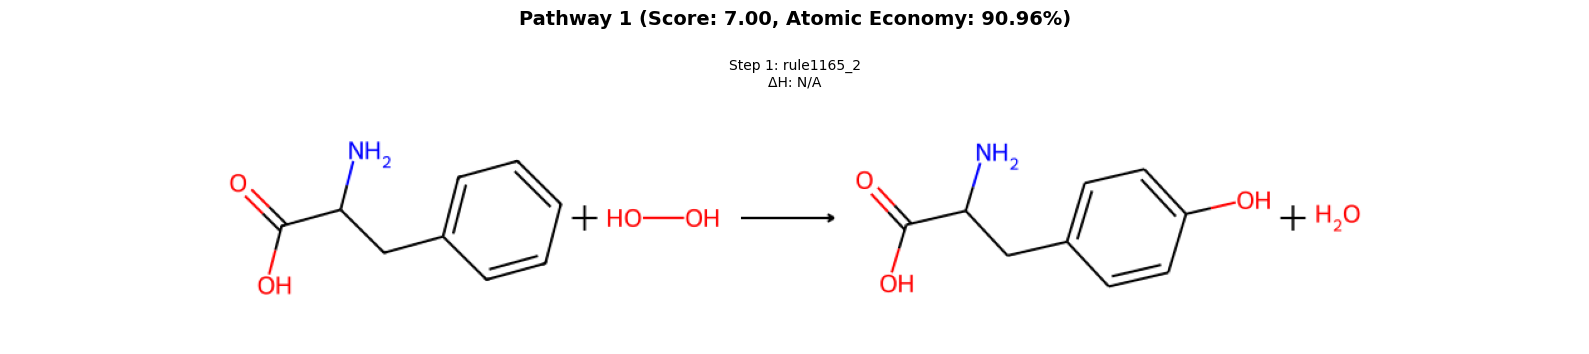

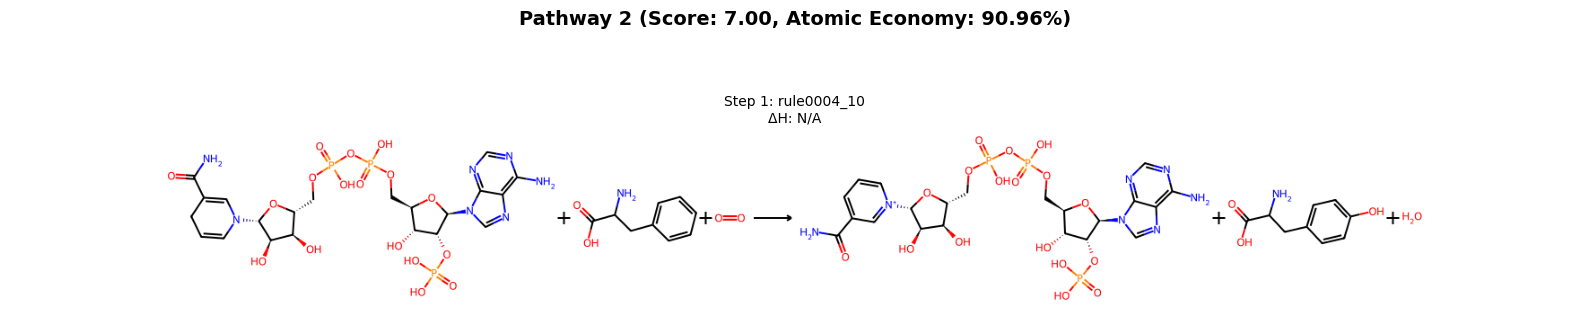

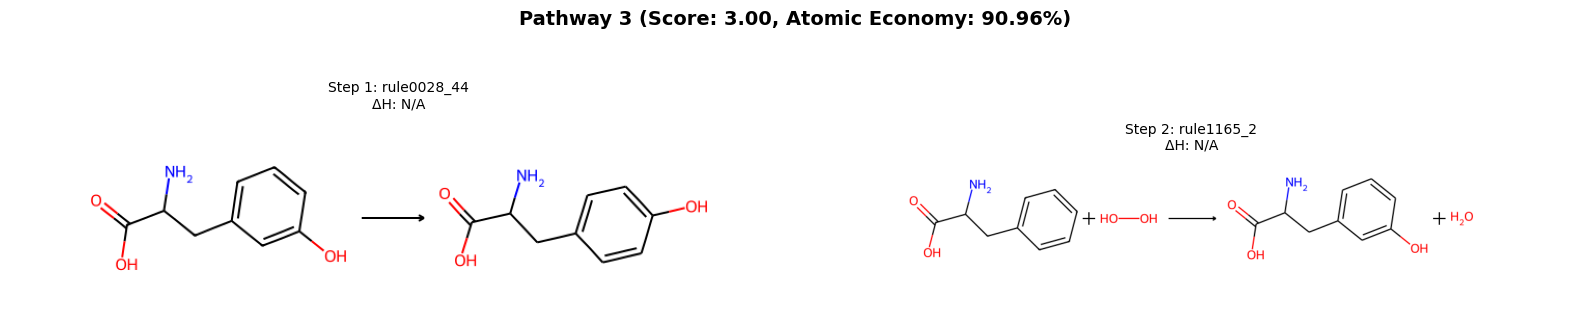

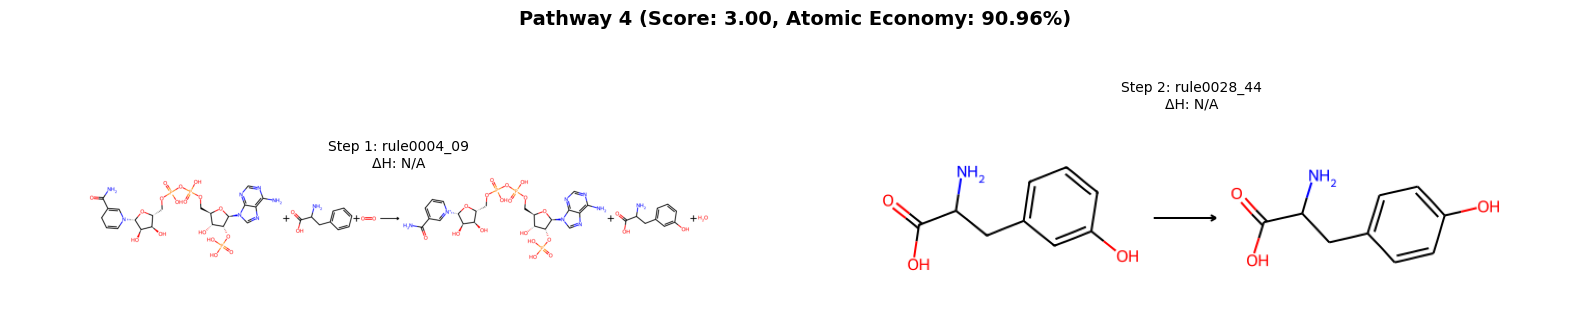

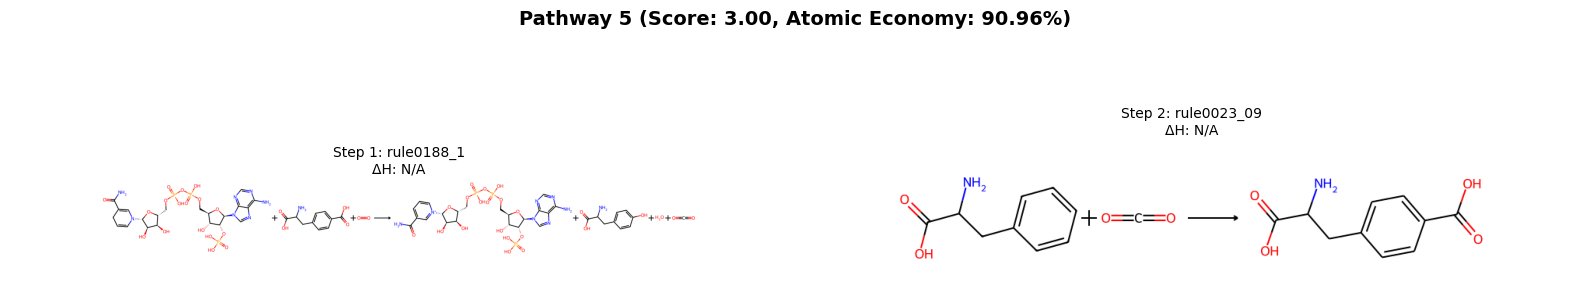

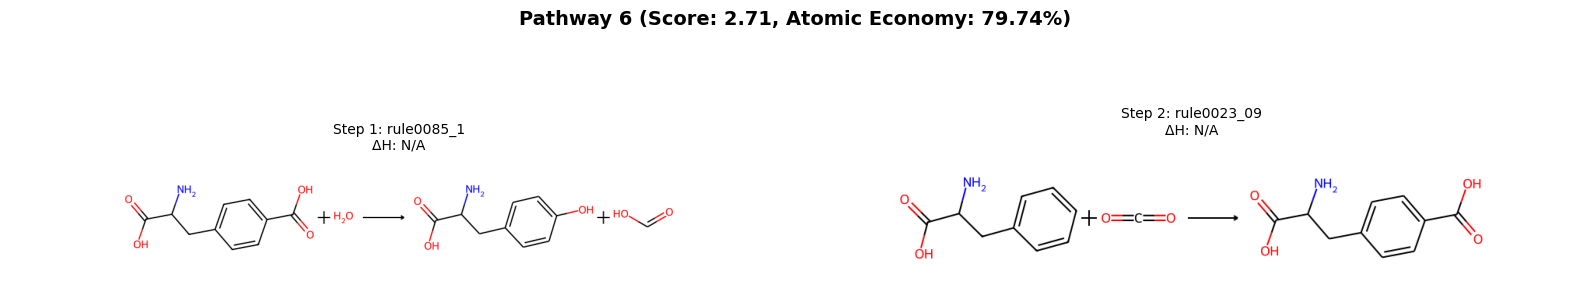

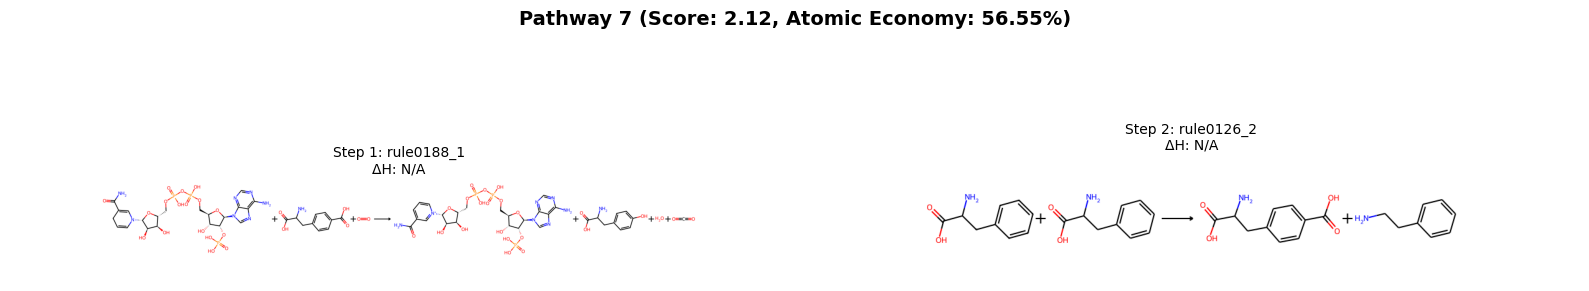

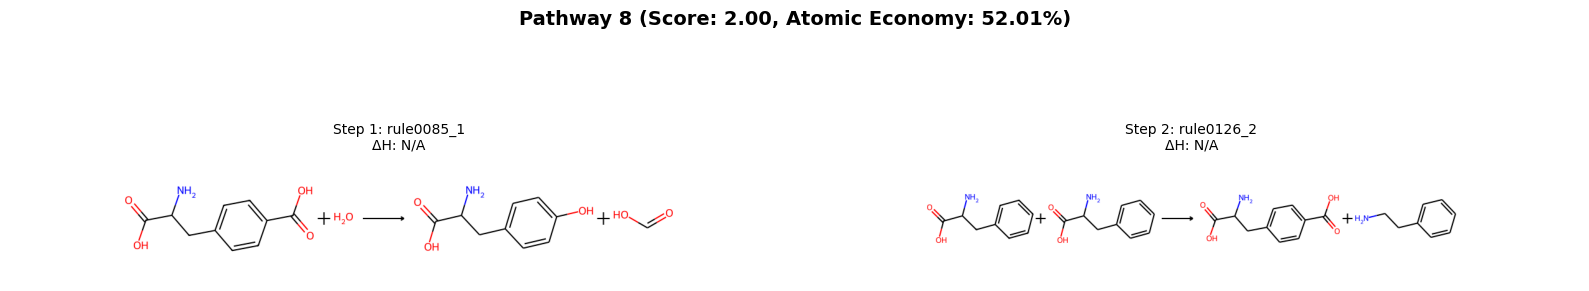

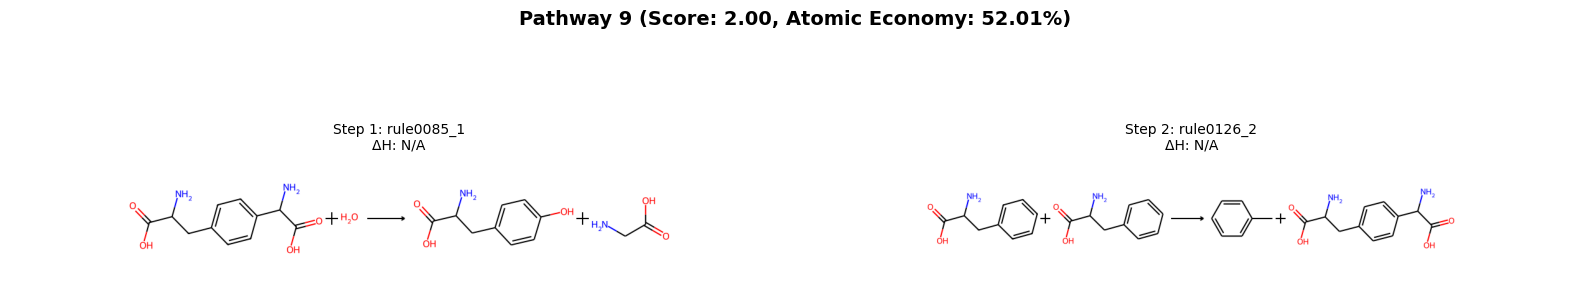

In [16]:
import re
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Tuple
import pandas as pd
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

try:
    from rdkit import Chem
    from rdkit.Chem import Draw, AllChem, rdMolDescriptors
    RDKIT_AVAILABLE = True
except ImportError:
    RDKIT_AVAILABLE = False

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150


@dataclass
class Reaction:
    smiles: str
    ruleName: str
    enthalpy: Optional[float]
    reactants: List[str] = field(default_factory=list)
    products: List[str] = field(default_factory=list)
    
    def __post_init__(self):
        if self.smiles and '>>' in self.smiles:
            reactantsStr, productsStr = self.smiles.split('>>')
            self.reactants = reactantsStr.split('.')
            self.products = productsStr.split('.')


@dataclass
class Pathway:
    ranking: int
    finalScore: float
    atomicEconomy: float
    pathwayByproduct: int
    intermediateByproduct: Dict
    reactions: List[Reaction] = field(default_factory=list)


def isNumeric(s: str) -> bool:
    try:
        float(s)
        return True
    except ValueError:
        return False


def parseSinglePathway(block: str) -> Optional[Pathway]:
    lines = block.strip().split('\n')
    ranking, finalScore, atomicEconomy = None, None, None
    pathwayByproduct, intermediateByproduct, reactions = 0, {}, []
    
    i = 0
    while i < len(lines):
        line = lines[i].strip()
        
        if line.startswith('ranking '):
            ranking = int(line.split()[1])
        elif line.startswith('final score '):
            finalScore = float(line.split()[-1])
        elif line.startswith('atomic economy '):
            atomicEconomy = float(line.split()[-1])
        elif line.startswith('pathway by-product '):
            pathwayByproduct = int(line.split()[-1])
        elif line.startswith('intermediate by-product '):
            dictStr = line.replace('intermediate by-product ', '')
            try:
                intermediateByproduct = eval(dictStr)
            except:
                intermediateByproduct = {}
        elif line.startswith('reaction SMILES'):
            i += 1
            reactionSmiles, ruleNames, enthalpies = [], [], []
            
            while i < len(lines) and '>>' in lines[i]:
                reactionSmiles.append(lines[i].strip())
                i += 1
            while i < len(lines) and lines[i].strip().startswith('rule'):
                ruleNames.append(lines[i].strip())
                i += 1
            while i < len(lines) and (lines[i].strip() == 'No_Thermo' or isNumeric(lines[i].strip())):
                enth = lines[i].strip()
                enthalpies.append(None if enth == 'No_Thermo' else float(enth))
                i += 1
            
            for j, smi in enumerate(reactionSmiles):
                rule = ruleNames[j] if j < len(ruleNames) else 'unknown'
                enth = enthalpies[j] if j < len(enthalpies) else None
                reactions.append(Reaction(smiles=smi, ruleName=rule, enthalpy=enth))
            continue
        i += 1
    
    if ranking is not None and finalScore is not None:
        return Pathway(ranking=ranking, finalScore=finalScore, atomicEconomy=atomicEconomy,
                      pathwayByproduct=pathwayByproduct, intermediateByproduct=intermediateByproduct,
                      reactions=reactions)
    return None


def parsePathwayFile(filepath: str) -> List[Pathway]:
    with open(filepath, 'r', encoding='utf-8') as f:
        content = f.read()
    
    pathways = []
    rankingBlocks = re.split(r'\n(?=ranking \d+)', content.strip())
    
    for block in rankingBlocks:
        if block.strip():
            pathway = parseSinglePathway(block)
            if pathway:
                pathways.append(pathway)
    return pathways


def getPathwaySummaryDataFrame(pathways: List[Pathway]) -> pd.DataFrame:
    data = []
    for p in sorted(pathways, key=lambda x: x.ranking):
        rules = ', '.join([r.ruleName for r in p.reactions])
        data.append({
            'Rank': p.ranking,
            'FinalScore': round(p.finalScore, 2),
            'AtomicEconomy': f"{p.atomicEconomy*100:.1f}%",
            'Steps': len(p.reactions),
            'Byproducts': p.pathwayByproduct,
            'Rules': rules
        })
    return pd.DataFrame(data)


def visualizeReactionDetails(pathway: Pathway, figsize: Tuple[int, int] = (16, 4)):
    if not RDKIT_AVAILABLE:
        return None
    
    nReactions = len(pathway.reactions)
    fig, axes = plt.subplots(1, nReactions, figsize=(figsize[0], figsize[1]))
    
    if nReactions == 1:
        axes = [axes]
    
    fig.suptitle(f'Pathway {pathway.ranking} (Score: {pathway.finalScore:.2f}, Atomic Economy: {pathway.atomicEconomy:.2%})',
                 fontsize=14, fontweight='bold')
    
    for idx, (rxn, ax) in enumerate(zip(pathway.reactions, axes)):
        try:
            rxnObj = AllChem.ReactionFromSmarts(rxn.smiles, useSmiles=True)
            img = Draw.ReactionToImage(rxnObj, subImgSize=(250, 200))
            ax.imshow(img)
            enthalpyStr = f'ΔH: {rxn.enthalpy:.2f} kJ/mol' if rxn.enthalpy else 'ΔH: N/A'
            ax.set_title(f'Step {idx + 1}: {rxn.ruleName}\n{enthalpyStr}', fontsize=10, pad=5)
        except:
            ax.text(0.5, 0.5, f'Step {idx + 1}\n{rxn.ruleName}\n{rxn.smiles[:40]}...', 
                   ha='center', va='center', fontsize=8, wrap=True, transform=ax.transAxes, family='monospace')
        ax.axis('off')
    
    plt.tight_layout()
    return fig


# execution
filePath = "phe_to_tyr_test_ranked_pathways.txt"

pathways = parsePathwayFile(filePath)

summaryDf = getPathwaySummaryDataFrame(pathways)
display(summaryDf)

topPathways = sorted(pathways, key=lambda x: x.ranking)[:10]

if RDKIT_AVAILABLE:
    for pathway in topPathways:
        visualizeReactionDetails(pathway)
        plt.show()